# Step 9 — MiniImageNet as a second in-distribution dataset  (Phase 5, RQ2/RQ3 breadth)  ·  Kaggle

Adds **MiniImageNet** (Ravi & Larochelle 2017, 64/16/20 split) alongside CIFAR-FS
so RQ2 (calibration) and RQ3 (near-OOD) can be claimed with cross-dataset
breadth, and so Step 10's MVT grid has its second `datasets` axis.

**Known confound, measured not just caveated:** MiniImageNet's 100 classes are
all in ILSVRC-2012, and both frozen backbones are ImageNet-pretrained — the
"novel" test classes were seen during pretraining. Expect near-saturated
accuracy. The two `linear_probe` reference runs below turn this into a number:
`(parallel accuracy − linear_probe accuracy)` is the adapter's uplift over raw
frozen features, directly comparable to the CIFAR-FS uplift already on record
(`phase3_linear_probe`: 0.8741 vs `phase4_parallel`: 0.915, i.e. **+4.1pp**).

**What this notebook runs** — 10 configs × (train + 600-episode eval):

| config | backbone | placement | head | result suffix |
|---|---|---|---|---|
| `exp_phase5_mini_postpool_evidential` | ResNet-18 | post_pool | evidential | `phase5_mini_postpool` |
| `exp_phase5_mini_postpool_softmax` | ResNet-18 | post_pool | softmax | `phase5_mini_postpool` |
| `exp_phase5_mini_parallel_evidential` | ResNet-18 | **parallel** (Step-6 winner) | evidential | `phase5_mini_parallel` |
| `exp_phase5_mini_parallel_softmax` | ResNet-18 | **parallel** | softmax | `phase5_mini_parallel` |
| `exp_phase5_mini_mbnet_postpool_evidential` | MobileNetV3-Small | post_pool | evidential | `phase5_mini_mbnet_postpool` |
| `exp_phase5_mini_mbnet_postpool_softmax` | MobileNetV3-Small | post_pool | softmax | `phase5_mini_mbnet_postpool` |
| `exp_phase5_mini_mbnet_parallel_evidential` | MobileNetV3-Small | **parallel** | evidential | `phase5_mini_mbnet_parallel` |
| `exp_phase5_mini_mbnet_parallel_softmax` | MobileNetV3-Small | **parallel** | softmax | `phase5_mini_mbnet_parallel` |
| `exp_phase5_mini_linear_probe_evidential` | ResNet-18 | *(no adapter)* | evidential | `phase5_mini` |
| `exp_phase5_mini_linear_probe_softmax` | ResNet-18 | *(no adapter)* | softmax | `phase5_mini` |

Everything except the dataset (and, for 4 rows, the backbone) is held fixed at
the Step-4.5 retuned recipe — same adapter form/rank, same cosine prototype
metric, same R-EDL loss knobs, same LR, same episodic schedule — so the
comparison isolates the **dataset** axis. Per-dataset VAL re-tuning stays a
Step 10 carry-over, same caveat Step 8 carried for MobileNetV3.

**What you get out** (all under `/kaggle/working/thesis`, plus a single zip at
`/kaggle/working` — see the last section):
* `results/phase5_mini*_metrics.json` — 10 result JSONs (600 episodes each)
* `results/phase5_dataset_table.json` — the cross-dataset table (CIFAR-FS vs MiniImageNet)
* `results/step9_dataset_comparison.png`, `results/step9_adapter_uplift.png`
* `checkpoints/model_phase2_mini_*_prototype-{evidential,softmax}_seed42.pt`
  — the 10 trained adapters (**the models**)

**Kaggle settings:** Accelerator = **GPU T4**, Internet = **ON**. No dataset
attachment is strictly required — CIFAR-100/MiniImageNet/SVHN/TinyImageNet all
download at runtime if not attached (~1.8 GB one-time for MiniImageNet); attach
what you can via `+ Add Input` to save time and avoid depending on
cs.toronto.edu's slower host. Then run top to bottom (~2-2.5 h; budget ~8 min
extra the first time for the MiniImageNet cache build). Expect the Section-7
run cell to be the long one.


## How we work with the data in this project (read before running)

These are the standing rules for every experiment in this repo. They are what
makes results comparable across runs, steps and machines — breaking one silently
invalidates a comparison rather than crashing, so they matter more than they look.

### 1. In-distribution data: CIFAR-FS with the frozen Bertinetto split
* Source is plain **CIFAR-100** (`data/cifar-100-python.tar.gz`), re-partitioned
  into the canonical **Bertinetto 2019 64/16/20 class split** — 64 meta-train,
  16 meta-val, 20 meta-test classes, **pairwise disjoint**, union = all 100.
* The split lives in `data/cifar_fs_split.json` and is **FROZEN — never
  regenerate or hand-edit it.** `scripts/build_cifar_fs_split.py` re-materialises
  the same canonical file after a fresh clone (`data/` is gitignored).

### 2. In-distribution data #2 (Step 9): MiniImageNet with the frozen Ravi & Larochelle split
* 64/16/20 **wnid** (WordNet ID) split, frozen as `MINI_IMAGENET_SPLIT` in
  `src/datasets/mini_imagenet.py` and re-materialised to
  `data/mini_imagenet_split.json` by `scripts/build_mini_imagenet_split.py`
  (same "FROZEN, do not hand-edit" convention as CIFAR-FS's split file).
* Unlike CIFAR-FS, there is no single upstream Dataset to filter by class id —
  every source layout is already split by design. The loader
  (`src/datasets/mini_imagenet.py:_ensure_cache`) auto-discovers, in order:
  (1) the 3 Zenodo `mini-imagenet-cache-{train,validation,test}.pkl` caches
  (record 7978538, MD5-checked), (2) an `images/` + `{train,val,test}.csv`
  layout (Ravi & Larochelle's own release shape), (3) a `<wnid>/*.jpg`
  imagefolder — staged under `data/` or an attached Kaggle dataset (searched
  under `/kaggle/input`) — and (4) downloads the Zenodo pkls if nothing is
  staged. Whichever is found, images are decoded ONCE into a per-split uint8
  `(N,84,84,3)` memmap-able cache (`data/mini_imagenet_84_<split>.npy` + a JSON
  sidecar), so a re-run never re-decodes.
* **Known confound (not a bug):** MiniImageNet's 100 classes are all in
  ILSVRC-2012, and both frozen backbones are ImageNet-pretrained — every
  MiniImageNet "novel" test class was seen during pretraining. See the
  linear-probe reference runs above for how this is measured, not just
  caveated.

### 3. Episodes are sampled from seeds, not shuffled
Every episode (5-way, 5-shot support + 15-query) is drawn by a **deterministic
per-episode seed**, so "episode 37" is the same 100 images for everyone, for
BOTH datasets (the seed streams are dataset-agnostic — the same
`configs/test_episodes.yaml` / `configs/val_episodes.yaml` pair CIFAR-FS and
MiniImageNet episode-index-for-episode-index):

| stream | seeds | file | rule |
|---|---|---|---|
| **test** | `0..599` | `configs/test_episodes.yaml` | **frozen**; 600 episodes; report on these |
| **val** | `10000..10099` | `configs/val_episodes.yaml` | **frozen**; early stopping + all tuning |
| **train** | `20000+` | `cfg.trainer.train_seed_offset` | new offset each epoch, so epochs don't repeat episodes |

### 4. The one rule that protects the whole thesis: tune on VAL only
Any hyperparameter choice — LR, KL weight, evidence affine, rank, placement,
temperature — is selected on the **val** stream (seeds 10000-10099). The **600
test seeds are touched exactly once, to report.** This notebook deliberately
reuses the ResNet-18 VAL-tuned recipe UNCHANGED on MiniImageNet (isolates the
dataset axis); per-dataset re-tuning is Step 10's job.

### 5. OOD pools (evaluated per episode against that episode's prototypes)
| pool | regime | source | n | which runs |
|---|---|---|---|---|
| `svhn_far` | far | SVHN test (`data/svhn/test_32x32.mat`) | 500 | all |
| `gaussian_far` | far | seeded N(0,1), clamped [-3,3] — sanity check | 500 | all |
| `cifar100_near` | near | 16 CIFAR-FS **val** classes | 500 | cifar_fs runs |
| `mini_near` | near | 16 MiniImageNet **val** classes (Step 9) | 500 | mini_imagenet runs |
| `tin_near` | near | TinyImageNet train | 500 | all (`--use-tinyimagenet`) |

`get_heldout_near_ood` (`src/datasets/__init__.py`) picks `cifar100_near` vs
`mini_near` automatically from `cfg.dataset.name` — nothing to configure.

### 6. TinyImageNet ↔ MiniImageNet wnid overlap (Step 9 decision)
TinyImageNet-200 shares **25 wnids** with MiniImageNet's 100 classes — **5 of
them MiniImageNet TEST classes**. Left unfiltered, ~2.5% of the "OOD" pool
would be literal in-distribution images, biasing the one metric RQ3 rests on.
For `mini_imagenet` runs, `scripts/evaluate.py` passes
`exclude_wnids=MINI_IMAGENET_ALL_WNIDS` to `get_tinyimagenet_ood` (all 100
wnids, not just the 20 test ones) — the resulting `tin_near` pool draws from
the remaining 175/200 TinyImageNet classes only. **This means Step 9's
`tin_near` numbers are not directly comparable to Steps 4.5/7/8's `tin_near`**
(different 500 images) — `exclude_wnids=None` for `cifar_fs` runs keeps those
byte-identical to every earlier step.

### 7. Never extract many-file archives onto a network filesystem
TinyImageNet is a ~120k-file zip; MiniImageNet's imagefolder mirrors can be
similarly many-file. The rule: cache the **single archive**, copy it once to
local disk, and read only what's needed straight out of it — never extract.
`src/datasets/tinyimagenet_ood.py` does this already; MiniImageNet's Zenodo
pkls sidestep the issue entirely (3 large files, not 60k small ones).

### 8. Every loader can fetch its own data
`src/datasets/_robust_download.py:ensure_archive()` pre-fetches each archive
with a browser User-Agent, tries mirrors in order, prints progress, verifies
MD5 when given one (Step 9's Zenodo pkls always pass one), and abandons a
mirror after 10 minutes. **Consequence for this notebook: a missing dataset
file is a slow start, not a failure** — only CIFAR-100 is treated as a hard
requirement here, because its host is the unreliable one.

### 9. Determinism is a result, not a nicety
`set_seed()` seeds python/numpy/torch (CPU+CUDA) and forces
`cudnn.deterministic`; metrics are dumped with `sort_keys=True`. **The same
config run twice must produce a byte-identical `metrics.json`.** The JSON key
schema is likewise frozen — Step 9 adds no new top-level keys; dataset identity
lives in the result FILENAME, consolidated by `scripts/step9_dataset_compare.py`.

### 10. On Kaggle specifically
`data/` is gitignored, so nothing ships with the clone. Every dataset here
(`cifar-100-python.tar.gz`, `test_32x32.mat`, `tiny-imagenet-200.zip`, the 3
`mini-imagenet-cache-*.pkl` files) is an OPTIONAL cache — attach any you have
via `+ Add Input` to save time; anything not attached downloads at runtime,
which needs Internet ON. Nothing hard-fails just because a dataset isn't
attached.


## 0. GPU + environment check

In [1]:
import torch, sys
print('python:', sys.version.split()[0], '| torch:', torch.__version__)
print('cuda  :', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
assert torch.cuda.is_available(), 'Enable GPU: Settings > Accelerator > GPU T4'


python: 3.12.13 | torch: 2.10.0+cu128
cuda  : True | Tesla T4


## 1. Clone the repo + install deps

In [2]:
import os, subprocess
REPO_URL = 'https://github.com/notAvailable73/thesis.git'
BRANCH   = 'main'                      # <-- branch with the Step 9 commit
REPO_DIR = '/kaggle/working/thesis'
if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)
os.chdir(REPO_DIR)
print('cwd:', os.getcwd())
print(subprocess.run(['git', 'log', '--oneline', '-1'], capture_output=True, text=True).stdout.strip())
!pip -q install -r requirements.txt
for f in ['src/datasets/mini_imagenet.py',
          'scripts/build_mini_imagenet_split.py',
          'configs/exp_phase5_mini_parallel_evidential.yaml',
          'scripts/step9_dataset_compare.py']:
    assert os.path.exists(f), f'MISSING {f} — push the Step 9 commit to this BRANCH.'
print('Step 9 code present — good.')


Cloning into '/kaggle/working/thesis'...


cwd: /kaggle/working/thesis
6c42070 step 9 fix round 1
Step 9 code present — good.


## 2. Stage data from an attached Kaggle Dataset

Prints what is actually attached, then stages what it finds. **Nothing here is
a hard requirement** — CIFAR-100, SVHN, TinyImageNet and MiniImageNet all
download at runtime if they are not attached (Internet must be ON); an
attached dataset is just a cache that saves time. CIFAR-100 is worth attaching
if you can, since its host (`cs.toronto.edu`) is slower/403-prone —
`ensure_archive()` works around that with a browser User-Agent + 2 mirrors +
retries, but a pre-staged copy is still faster and more reliable than a fresh
download every session.

The MiniImageNet section only REPORTS what layout (if any) is already staged —
`src/datasets/mini_imagenet.py`'s own auto-discovery (imported directly here,
not reimplemented) does the actual copying/caching the first time
`get_mini_imagenet()` runs (Section 5).

In [3]:
import os, shutil, hashlib, glob
os.makedirs('data/svhn', exist_ok=True)
CIFAR_MD5 = 'eb9058c3a382ffc7106e4002c42a8d85'

def _find_file(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

def _find_cifar_root():
    for meta in glob.glob('/kaggle/input/**/meta', recursive=True):
        d = os.path.dirname(meta)
        if os.path.exists(os.path.join(d, 'train')) and os.path.exists(os.path.join(d, 'test')):
            return d
    return None

print('attached inputs under /kaggle/input:')
for d in sorted(glob.glob('/kaggle/input/*')):
    n = sum(len(f) for _r, _d, f in os.walk(d))
    print(f'  {d}  ({n} files)')
print()

# --- CIFAR-100 (in-distribution #1) --------------------------------------
# Soft, like SVHN/TinyImageNet below: prefer a staged copy (faster, avoids
# cs.toronto.edu's slow/403-prone host), but DO NOT hard-fail if nothing is
# attached -- get_cifar_fs() -> ensure_archive() already downloads CIFAR-100
# at runtime with a browser User-Agent + 2 mirrors + retries (needs Internet
# ON), the same mechanism every earlier step's fresh-clone-with-no-data/
# gitignored setup already relies on.
if os.path.isdir('data/cifar-100-python') or \
   (os.path.exists('data/cifar-100-python.tar.gz') and os.path.getsize('data/cifar-100-python.tar.gz') > 0):
    print('[cifar] already staged')
else:
    tar = _find_file('cifar-100-python.tar.gz'); root = _find_cifar_root()
    if tar:
        shutil.copy(tar, 'data/cifar-100-python.tar.gz')
        md5 = hashlib.md5(open('data/cifar-100-python.tar.gz','rb').read()).hexdigest()
        if md5 == CIFAR_MD5:
            print('[cifar] staged tarball (md5 OK)')
        else:
            print(f'[cifar] WARNING: staged tarball md5 {md5} != expected {CIFAR_MD5} -- '
                  'removing it and falling back to runtime download instead of trusting a bad file.')
            os.remove('data/cifar-100-python.tar.gz')
    elif root:
        shutil.copytree(root, 'data/cifar-100-python')
        print(f'[cifar] copied extracted files from {root}')
    else:
        print('[cifar] NOT found under /kaggle/input -- will download at runtime from '
              'cs.toronto.edu (needs Internet ON; this host is slower/403-prone, which is '
              'why ensure_archive() pre-fetches it with a browser User-Agent + 2 mirrors + '
              'retries). Attach a dataset with cifar-100-python.tar.gz to skip this and save '
              'a few minutes on future runs.')

# --- SVHN (far-OOD) -------------------------------------------------------
dst = 'data/svhn/test_32x32.mat'
if os.path.exists(dst) and os.path.getsize(dst) > 0:
    print('[svhn] already present')
else:
    src = _find_file('test_32x32.mat')
    if src:
        shutil.copy(src, dst); print(f'[svhn] staged from dataset ({os.path.getsize(dst)/1e6:.0f} MB)')
    else:
        print('[svhn] NOT in /kaggle/input — will download at runtime (needs Internet ON).')

# --- TinyImageNet (near-OOD corroboration) --------------------------------
tin = _find_file('tiny-imagenet-200.zip')
if tin: shutil.copy(tin, 'data/tiny-imagenet-200.zip'); print('[tin] staged zip from dataset (NOT extracted)')
else:   print('[tin] not in dataset — downloads at runtime (Internet ON)')

# --- MiniImageNet (in-distribution #2, Step 9) ----------------------------
import sys
sys.path.insert(0, '.')
from src.datasets.mini_imagenet import (
    _find_zenodo_pkls, _find_csv_layout, _find_imagefolder_layout)
pkls = _find_zenodo_pkls('data')
csvs = _find_csv_layout('data')
folder = _find_imagefolder_layout('data')
if pkls:
    print(f'[miniimagenet] found the 3 Zenodo cache pkls staged: {sorted(pkls.values())}')
elif csvs:
    print(f'[miniimagenet] found an images/+csv layout at {csvs}')
elif folder:
    print(f'[miniimagenet] found a wnid-imagefolder layout at {folder}')
else:
    print('[miniimagenet] nothing staged — will download the 3 Zenodo cache '
          'pkls (record 7978538, ~1.8 GB total, MD5-checked) at first use '
          '(needs Internet ON, Section 5). Attach a MiniImageNet dataset to '
          'skip this on future runs.')


attached inputs under /kaggle/input:
  /kaggle/input/datasets  (0 files)

[cifar] NOT found under /kaggle/input -- will download at runtime from cs.toronto.edu (needs Internet ON; this host is slower/403-prone, which is why ensure_archive() pre-fetches it with a browser User-Agent + 2 mirrors + retries). Attach a dataset with cifar-100-python.tar.gz to skip this and save a few minutes on future runs.
[svhn] NOT in /kaggle/input — will download at runtime (needs Internet ON).
[tin] not in dataset — downloads at runtime (Internet ON)
[miniimagenet] nothing staged — will download the 3 Zenodo cache pkls (record 7978538, ~1.8 GB total, MD5-checked) at first use (needs Internet ON, Section 5). Attach a MiniImageNet dataset to skip this on future runs.


### 2b. Verify a manually-added CIFAR-100 before staging/testing

Read-only — no copying, no side effects. Run this right after you attach/upload the
CIFAR-100 dataset (before or after the Section 2 staging cell above; it checks both
`/kaggle/input` and `data/`) to confirm the exact path Kaggle mounted it at, that the
filename/extracted layout matches what `ensure_archive()` looks for, and that the MD5
is correct before burning time on Section 4's tests or a full training run.

In [ ]:
import os, glob, hashlib

CIFAR_FILENAME = 'cifar-100-python.tar.gz'
CIFAR_MD5 = 'eb9058c3a382ffc7106e4002c42a8d85'

def md5_of(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

print('=== 1. everything Kaggle currently sees under /kaggle/input ===')
found_any = False
for p in sorted(glob.glob('/kaggle/input/**/*', recursive=True)):
    if os.path.isfile(p):
        found_any = True
        print(f'  {p}  ({os.path.getsize(p)/1e6:.1f} MB)')
if not found_any:
    print('  (nothing attached yet -- attach/add the dataset, then re-run this cell)')

print()
print(f'=== 2. exact match for {CIFAR_FILENAME!r} under /kaggle/input ===')
hits = glob.glob(f'/kaggle/input/**/{CIFAR_FILENAME}', recursive=True)
if not hits:
    print('  not found by exact filename')
for h in hits:
    md5 = md5_of(h)
    verdict = 'MD5 OK' if md5 == CIFAR_MD5 else f'MD5 MISMATCH (expected {CIFAR_MD5})'
    print(f'  {h}')
    print(f'    size={os.path.getsize(h)/1e6:.1f} MB  md5={md5}  [{verdict}]')

print()
print('=== 3. already-extracted layout (a "meta" file alongside train/ + test/) ===')
roots = []
for meta in glob.glob('/kaggle/input/**/meta', recursive=True):
    d = os.path.dirname(meta)
    has_train = os.path.exists(os.path.join(d, 'train'))
    has_test = os.path.exists(os.path.join(d, 'test'))
    print(f'  {d}  train={has_train} test={has_test}')
    if has_train and has_test:
        roots.append(d)
if not roots and not hits:
    print('  none found')

print()
print('=== 4. current state of data/ (what get_cifar_fs() will actually read) ===')
tar_dst = 'data/cifar-100-python.tar.gz'
dir_dst = 'data/cifar-100-python'
if os.path.isdir(dir_dst):
    print(f'  {dir_dst}/ exists -- ensure_archive() will short-circuit and use it directly')
elif os.path.exists(tar_dst) and os.path.getsize(tar_dst) > 0:
    md5 = md5_of(tar_dst)
    verdict = 'MD5 OK' if md5 == CIFAR_MD5 else f'MD5 MISMATCH (expected {CIFAR_MD5})'
    print(f'  {tar_dst}  size={os.path.getsize(tar_dst)/1e6:.1f} MB  md5={md5}  [{verdict}]')
else:
    print('  nothing staged in data/ yet -- run the Section 2 staging cell next')

print()
print('=== verdict ===')
if os.path.isdir(dir_dst) or (os.path.exists(tar_dst) and os.path.getsize(tar_dst) > 0):
    print('data/ already has CIFAR-100 -- Section 4 tests should not need to download it.')
elif hits or roots:
    print('CIFAR-100 is attached under /kaggle/input -- run the Section 2 staging cell to copy it into data/.')
else:
    print('CIFAR-100 is NOT visible under /kaggle/input yet -- attach/add the dataset and re-run this cell.')

### 2c. Confirm torchvision actually accepts the staged files

Existence of `data/cifar-100-python/{train,test,meta}` isn't proof they're the *correct*
bytes -- `torchvision.datasets.CIFAR100` computes its own MD5 over each file and refuses
to load on a mismatch. This instantiates it with `download=False` (a few seconds, no
network) so a bad/partial copy fails here instead of 80 minutes into Section 4's tests.

In [ ]:
import torchvision

for split, train in (('train', True), ('test', False)):
    try:
        ds = torchvision.datasets.CIFAR100(root='data', train=train, download=False)
        print(f'[cifar] {split}: OK -- {len(ds)} images, MD5 integrity check passed')
    except Exception as e:
        print(f'[cifar] {split}: FAILED -- {e}')

## 3. Build the frozen splits (CIFAR-FS + MiniImageNet)

Re-materialises both canonical split files. The asserts guard against silently
training on a synthetic fallback.

In [4]:
!python scripts/build_cifar_fs_split.py
!python scripts/build_mini_imagenet_split.py
import json
sp_c = json.load(open('data/cifar_fs_split.json'))
sp_m = json.load(open('data/mini_imagenet_split.json'))
print('CIFAR-FS     split status:', sp_c.get('_status'),
      '| sizes:', {k: len(v) for k, v in sp_c.items() if isinstance(v, list)})
print('MiniImageNet split status:', sp_m.get('_status'),
      '| sizes:', {k: len(v) for k, v in sp_m.items() if isinstance(v, list)})
assert sp_c.get('_status') != 'synthetic_fallback', 'CIFAR-FS split is the SYNTHETIC fallback — fix before running'
assert sp_m.get('_status') != 'synthetic_fallback', 'MiniImageNet split is the SYNTHETIC fallback — fix before running'


wrote /kaggle/working/thesis/data/cifar_fs_split.json  (64/16/20, disjoint, union=100, status=canonical_bertinetto_via_torchmeta)
wrote /kaggle/working/thesis/data/mini_imagenet_split.json  (64/16/20, disjoint, union=100, status=canonical_ravi_larochelle)
CIFAR-FS     split status: canonical_bertinetto_via_torchmeta | sizes: {'train': 64, 'val': 16, 'test': 20}
MiniImageNet split status: canonical_ravi_larochelle | sizes: {'train': 64, 'val': 16, 'test': 20}


## 4. Tests

`test_mini_imagenet.py` + `test_dataset_dispatch.py` are the new Step 9
suites; `test_tinyimagenet_ood.py` gained `exclude_wnids` coverage. All three
are offline (synthetic fixtures / frozen constants) — no MiniImageNet download
needed to run them.

In [5]:
!python -u -m pytest -q -s tests/test_mini_imagenet.py tests/test_dataset_dispatch.py tests/test_tinyimagenet_ood.py

.............................FFFF...                                     [100%]
=================================== FAILURES ===================================
________________ test_get_id_split_cifar_fs_matches_direct_call ________________

    def test_get_id_split_cifar_fs_matches_direct_call():
>       direct = ds.get_cifar_fs(data_root="data", image_size=32, split="test")
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

tests/test_dataset_dispatch.py:119: 
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
src/datasets/cifar_fs.py:192: in get_cifar_fs
    ensure_archive(
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 

data_root = 'data', filename = 'cifar-100-python.tar.gz'
urls = ['https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz', 'http://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz']
extracted_dirname = 'cifar-100-python', total_timeout = 600.0, md5 = None
user_agent = '

In [ ]:
# Full suite (Steps 1-9). Expect ~170 (135 + 35 new Step 9 tests).
!python -u -m pytest -q -s

.........................FF............................................. [ 42%]
........................................................................ [ 84%]
.....................FF...                                               [100%]
=================================== FAILURES ===================================
________________ test_get_id_split_cifar_fs_matches_direct_call ________________

    def test_get_id_split_cifar_fs_matches_direct_call():
>       direct = ds.get_cifar_fs(data_root="data", image_size=32, split="test")
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

tests/test_dataset_dispatch.py:119: 
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
src/datasets/cifar_fs.py:192: in get_cifar_fs
    ensure_archive(
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 

data_root = 'data', filename = 'cifar-100-python.tar.gz'
urls = ['https://www.cs.toronto.edu/~kriz/cifar-100-pyt

## 5. MiniImageNet cache build (separate, TIMED cell)

Decodes all 3 splits into the per-split uint8 `.npy` cache once — the ~1.8 GB
download (if not staged) plus decode happens here, not silently inside the
first training run, so a slow step is visible as a step rather than looking
like a hang.

In [7]:
import time, sys
sys.path.insert(0, '.')
from src.datasets.mini_imagenet import get_mini_imagenet, MINI_IMAGENET_ALL_WNIDS

DELETE_PKLS_AFTER_CACHE = False  # set True to free ~1.8GB of disk after caching
                                 # (only if disk space is tight -- the npy
                                 # caches built below are all get_mini_imagenet
                                 # needs afterwards; the notebook does NOT do
                                 # this by default in case you want to inspect
                                 # or re-share the raw pkls)

t0 = time.time()
splits = {}
for split in ('train', 'val', 'test'):
    ds = get_mini_imagenet(data_root='data', image_size=224, split=split)
    splits[split] = ds
    print(f'[{split}] {len(ds)} images, {len(ds.wnids)} classes '
          f'({time.time()-t0:.0f}s elapsed)')

print(f'\ntotal cache build: {time.time()-t0:.0f}s')
assert len(splits['train'].wnids) == 64
assert len(splits['val'].wnids) == 16
assert len(splits['test'].wnids) == 20
assert (set(splits['train'].wnids) | set(splits['val'].wnids)
        | set(splits['test'].wnids)) == MINI_IMAGENET_ALL_WNIDS
print('split sizes + disjointness OK')

if DELETE_PKLS_AFTER_CACHE:
    import glob, os
    for p in glob.glob('data/mini-imagenet-cache-*.pkl'):
        os.remove(p); print(f'removed {p}')


[download] mini-imagenet-cache-train.pkl <- https://zenodo.org/records/7978538/files/mini-imagenet-cache-train.pkl  (1145 MB)
[download]   17 MB (1%)
[download]   34 MB (3%)
[download]   50 MB (4%)
[download]   67 MB (6%)
[download]   84 MB (7%)
[download]   101 MB (9%)
[download]   117 MB (10%)
[download]   134 MB (12%)
[download]   151 MB (13%)
[download]   168 MB (15%)
[download]   185 MB (16%)
[download]   201 MB (18%)
[download]   218 MB (19%)
[download]   235 MB (21%)
[download]   252 MB (22%)
[download]   268 MB (23%)
[download]   285 MB (25%)
[download]   302 MB (26%)
[download]   319 MB (28%)
[download]   336 MB (29%)
[download]   352 MB (31%)
[download]   369 MB (32%)
[download]   386 MB (34%)
[download]   403 MB (35%)
[download]   419 MB (37%)
[download]   436 MB (38%)
[download]   453 MB (40%)
[download]   470 MB (41%)
[download]   487 MB (42%)
[download]   503 MB (44%)
[download]   520 MB (45%)
[download]   537 MB (47%)
[download]   554 MB (48%)
[download]   570 MB (50%)
[

### 5b. TinyImageNet ↔ MiniImageNet overlap report

Documents (doesn't just assert) the Section-1-rule-6 filtering decision, by
reading TinyImageNet's wnids straight from its zip's directory names (no
extraction) once it's staged/downloaded.

In [8]:
import zipfile, os
from src.datasets.mini_imagenet import MINI_IMAGENET_SPLIT

tin_zip = 'data/tiny-imagenet-200.zip'
if not os.path.exists(tin_zip):
    print('[tin overlap] tiny-imagenet-200.zip not staged yet -- it downloads '
          'automatically the first time a run below evaluates with '
          '--use-tinyimagenet (Section 7); re-run this cell afterwards.')
else:
    with zipfile.ZipFile(tin_zip) as z:
        tin_wnids = {n.split('/train/', 1)[1].split('/', 1)[0]
                     for n in z.namelist() if '/train/' in n}
    overlap = tin_wnids & MINI_IMAGENET_ALL_WNIDS
    overlap_test = overlap & set(MINI_IMAGENET_SPLIT['test'])
    print(f'TinyImageNet wnids           : {len(tin_wnids)}')
    print(f'shared with MiniImageNet(100): {len(overlap)}  -> {sorted(overlap)}')
    print(f'shared with MiniImageNet TEST: {len(overlap_test)}  -> {sorted(overlap_test)}')
    print('\nThese are excluded from tin_near for every mini_imagenet run via '
          'exclude_wnids=MINI_IMAGENET_ALL_WNIDS (scripts/evaluate.py) -- '
          'cifar_fs runs pass exclude_wnids=None and stay byte-identical to '
          'every earlier step.')


[tin overlap] tiny-imagenet-200.zip not staged yet -- it downloads automatically the first time a run below evaluates with --use-tinyimagenet (Section 7); re-run this cell afterwards.


## 6. Config sanity check — trainable params per Step 9 config

Cheap, and it verifies the two things most likely to be silently wrong: that
every config actually resolved `dataset.name: mini_imagenet`, and that its
trainable-param count matches the CIFAR-FS sibling (same adapter form/rank —
only the dataset differs).

In [9]:
from src.utils import count_trainable_params, load_config
from src.models import build_model

CONFIGS = [
    'exp_phase5_mini_postpool_evidential', 'exp_phase5_mini_postpool_softmax',
    'exp_phase5_mini_parallel_evidential', 'exp_phase5_mini_parallel_softmax',
    'exp_phase5_mini_mbnet_postpool_evidential', 'exp_phase5_mini_mbnet_postpool_softmax',
    'exp_phase5_mini_mbnet_parallel_evidential', 'exp_phase5_mini_mbnet_parallel_softmax',
    'exp_phase5_mini_linear_probe_evidential', 'exp_phase5_mini_linear_probe_softmax',
]
for name in CONFIGS:
    cfg = load_config(f'configs/{name}.yaml')
    assert cfg.dataset.name == 'mini_imagenet', f'{name}: dataset.name did not resolve to mini_imagenet'
    m = build_model(cfg)
    ad = m.adapter
    where = (', '.join(f'{p}({c}ch)' for p, c in zip(ad.stage_paths, ad.stage_channels))
             if hasattr(ad, 'stage_paths') else getattr(ad, 'placement', 'linear_probe (no adapter)'))
    print(f'  {name:44s} backbone={cfg.backbone.name:18s} '
          f'{count_trainable_params(m):>8,d}   {where}')


  exp_phase5_mini_postpool_evidential          backbone=resnet18             16,914   linear_probe (no adapter)
  exp_phase5_mini_postpool_softmax             backbone=resnet18             16,912   linear_probe (no adapter)
  exp_phase5_mini_parallel_evidential          backbone=resnet18             31,746   layer1.1(64ch), layer2.1(128ch), layer3.1(256ch), layer4.1(512ch)
  exp_phase5_mini_parallel_softmax             backbone=resnet18             31,744   layer1.1(64ch), layer2.1(128ch), layer3.1(256ch), layer4.1(512ch)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 98.3MB/s]

  exp_phase5_mini_mbnet_postpool_evidential    backbone=mobilenetv3_small    19,026   linear_probe (no adapter)


  exp_phase5_mini_mbnet_postpool_softmax       backbone=mobilenetv3_small    19,024   linear_probe (no adapter)
  exp_phase5_mini_mbnet_parallel_evidential    backbone=mobilenetv3_small     6,930   features.3(24ch), features.6(40ch), features.8(48ch), features.11(96ch)
  exp_phase5_mini_mbnet_parallel_softmax       backbone=mobilenetv3_small     6,928   features.3(24ch), features.6(40ch), features.8(48ch), features.11(96ch)
  exp_phase5_mini_linear_probe_evidential      backbone=resnet18                  2   linear_probe (no adapter)
  exp_phase5_mini_linear_probe_softmax         backbone=resnet18                  0   linear_probe (no adapter)


## 7. Train + evaluate the 10 MiniImageNet configs

600 test episodes each, with the full OOD list (`--use-tinyimagenet
--use-gaussian`) so the mini rows line up column-for-column with the
committed CIFAR-FS rows.

Resumable: a config whose result JSON already exists is skipped, so a re-run
after a session timeout picks up where it stopped. The collapse guard
(`collapse_threshold: 0.25`) is left ON.

In [10]:
import subprocess, os, time
NUM_EPISODES = 600
RUNS = [
    # (config name, results-suffix)
    ('exp_phase5_mini_postpool_evidential',       'phase5_mini_postpool'),
    ('exp_phase5_mini_postpool_softmax',          'phase5_mini_postpool'),
    ('exp_phase5_mini_parallel_evidential',       'phase5_mini_parallel'),
    ('exp_phase5_mini_parallel_softmax',          'phase5_mini_parallel'),
    ('exp_phase5_mini_mbnet_postpool_evidential', 'phase5_mini_mbnet_postpool'),
    ('exp_phase5_mini_mbnet_postpool_softmax',    'phase5_mini_mbnet_postpool'),
    ('exp_phase5_mini_mbnet_parallel_evidential', 'phase5_mini_mbnet_parallel'),
    ('exp_phase5_mini_mbnet_parallel_softmax',    'phase5_mini_mbnet_parallel'),
    ('exp_phase5_mini_linear_probe_evidential',   'phase5_mini'),
    ('exp_phase5_mini_linear_probe_softmax',      'phase5_mini'),
]

def head_desc(name):
    return 'prototype-evidential' if name.endswith('evidential') else 'prototype-softmax'

def adapter_desc(name):
    return 'linear_probe' if 'linear_probe' in name else 'bottleneck'

def result_path(name, suffix):
    return f'results/{suffix}_{adapter_desc(name)}_{head_desc(name)}_metrics.json'

def run(cmd):
    print('>>>', ' '.join(cmd), flush=True)
    return subprocess.run(cmd).returncode

status = {}
for name, suffix in RUNS:
    out = result_path(name, suffix)
    if os.path.exists(out):
        print(f'== SKIP {name} (found {out}) =='); status[name] = 'skip (exists)'; continue
    print(f'\n{"="*72}\n== {name} ==\n{"="*72}', flush=True)
    t0 = time.time()
    cfg = f'configs/{name}.yaml'
    rc = run(['python', '-u', 'scripts/train.py', '--config', cfg, '--wandb-mode', 'disabled'])
    if rc != 0:
        status[name] = f'TRAIN failed (rc={rc})'; continue
    rc = run(['python', '-u', 'scripts/evaluate.py', '--config', cfg,
              '--num-episodes', str(NUM_EPISODES), '--wandb-mode', 'disabled',
              '--results-suffix', suffix, '--use-tinyimagenet', '--use-gaussian'])
    ok = (rc == 0 and os.path.exists(out))
    status[name] = f'OK ({(time.time()-t0)/60:.0f} min)' if ok else f'EVAL failed (rc={rc})'

print('\nRUN STATUS')
for name, _s in RUNS:
    print(f'  {name:44s} {status.get(name, "not run")}')



== exp_phase5_mini_postpool_evidential ==
>>> python -u scripts/train.py --config configs/exp_phase5_mini_postpool_evidential.yaml --wandb-mode disabled
[03:17:38] INFO bpeft.train: config: configs/exp_phase5_mini_postpool_evidential.yaml  seed: 42  trainer.type: episodic
[03:17:38] INFO bpeft.train: wandb: disabled (no-op logger)
[03:17:39] INFO bpeft.train: backbone: resnet18 (feature_dim=512)  adapter: bottleneck/post_pool
[03:17:39] INFO bpeft.train: trainable params: 16,914
[03:18:32] INFO bpeft.train: epoch   1/30  train_loss=0.3382  train_acc=0.932  val_loss=0.3926  val_acc=0.931  kl_w=0.010  mean_ev=1.6724  grad_norm=0.3603  global_step=100
[03:19:21] INFO bpeft.train: epoch   2/30  train_loss=0.2835  train_acc=0.929  val_loss=0.3705  val_acc=0.931  kl_w=0.020  mean_ev=1.6823  grad_norm=0.2526  global_step=200
[03:20:11] INFO bpeft.train: epoch   3/30  train_loss=0.2586  train_acc=0.935  val_loss=0.3356  val_acc=0.932  kl_w=0.030  mean_ev=2.0163  grad_norm=0.3336  global_step=

## 7b. OPTIONAL — 1-shot sweep (off by default; Step 10 owns the `shots` axis)

Step 9's exit criteria are 5-shot only. This block lets you extend today's
MiniImageNet runs to 1-shot ad hoc, by materializing a tiny child config per
run (`dataset.k_shot: 1`) rather than editing the committed configs. Leave
`RUN_ONESHOT = False` unless you specifically want this now.

In [11]:
RUN_ONESHOT = False

if RUN_ONESHOT:
    os.makedirs('configs/_oneshot', exist_ok=True)
    for name, suffix in RUNS:
        child = f'configs/_oneshot/{name}_1shot.yaml'
        if not os.path.exists(child):
            with open(child, 'w') as f:
                f.write(f'extends: ../{name}.yaml\ndataset:\n  k_shot: 1\n')
        oneshot_suffix = suffix + '_1shot'
        out = result_path(name, oneshot_suffix)
        if os.path.exists(out):
            print(f'== SKIP {name} (1-shot) (found {out}) =='); continue
        rc = run(['python', '-u', 'scripts/train.py', '--config', child, '--wandb-mode', 'disabled'])
        if rc != 0:
            print(f'{name} 1-shot TRAIN failed (rc={rc})'); continue
        run(['python', '-u', 'scripts/evaluate.py', '--config', child,
             '--num-episodes', str(NUM_EPISODES), '--wandb-mode', 'disabled',
             '--results-suffix', oneshot_suffix, '--use-tinyimagenet', '--use-gaussian'])
else:
    print('RUN_ONESHOT is False -- skipping the optional 1-shot sweep '
          '(Step 10 scope). Set RUN_ONESHOT = True above to run it anyway.')


RUN_ONESHOT is False -- skipping the optional 1-shot sweep (Step 10 scope). Set RUN_ONESHOT = True above to run it anyway.


## 8. Consolidate the cross-dataset table + plots

CIFAR-FS rows are read from the already-committed Step 4.5/5/6/7/8 JSONs — no
re-run, so those numbers are exactly as previously reported.

In [12]:
!python scripts/step9_dataset_compare.py

saved /kaggle/working/thesis/results/phase5_dataset_table.json

cell                       head            acc      F1     ECE   Brier    svhn    near     tin     params  bestEp
------------------------------------------------------------------------------------------------------------------------
cifar_fs/r18/post_pool     evidential    0.883   0.882   0.285   0.285   0.914   0.878   0.912     16,914       8
cifar_fs/r18/post_pool     softmax       0.875   0.873   0.082   0.191   0.838   0.744   0.790     16,912       2
cifar_fs/r18/parallel      evidential    0.915   0.913   0.282   0.242   0.933   0.912   0.929     31,746      19
cifar_fs/r18/parallel      softmax       0.912   0.911   0.063   0.134   0.887   0.814   0.848     31,744      10
cifar_fs/mbnet/post_pool   evidential    0.867   0.865   0.264   0.292   0.905   0.868   0.902     19,026      14
cifar_fs/mbnet/post_pool   softmax       0.872   0.870   0.064   0.190   0.836   0.765   0.798     19,024       1
cifar_fs/mbnet/pa

In [13]:
import json
print(json.dumps(json.load(open('results/phase5_dataset_table.json')), indent=2, sort_keys=True))


{
  "cells": {
    "cifar_fs/mbnet/parallel": {
      "backbone": "mobilenetv3_small",
      "dataset": "cifar_fs",
      "heads": {
        "evidential": {
          "accuracy_ci95": 0.0052,
          "accuracy_mean": 0.9048,
          "best_val_epoch": 3,
          "brier_mean": 0.2701,
          "ece_pooled": 0.3069,
          "f1_macro_mean": 0.9033,
          "n_params": 6930,
          "num_episodes": 600,
          "ood": {
            "gaussian_far": {
              "auroc": 0.9492,
              "fpr_at_95": 0.2104,
              "regime": "far"
            },
            "heldout_near": {
              "auroc": 0.8752,
              "fpr_at_95": 0.49,
              "regime": "near"
            },
            "svhn_far": {
              "auroc": 0.9522,
              "fpr_at_95": 0.2257,
              "regime": "far"
            },
            "tin_near": {
              "auroc": 0.9133,
              "fpr_at_95": 0.4054,
              "regime": "near"
            }
          

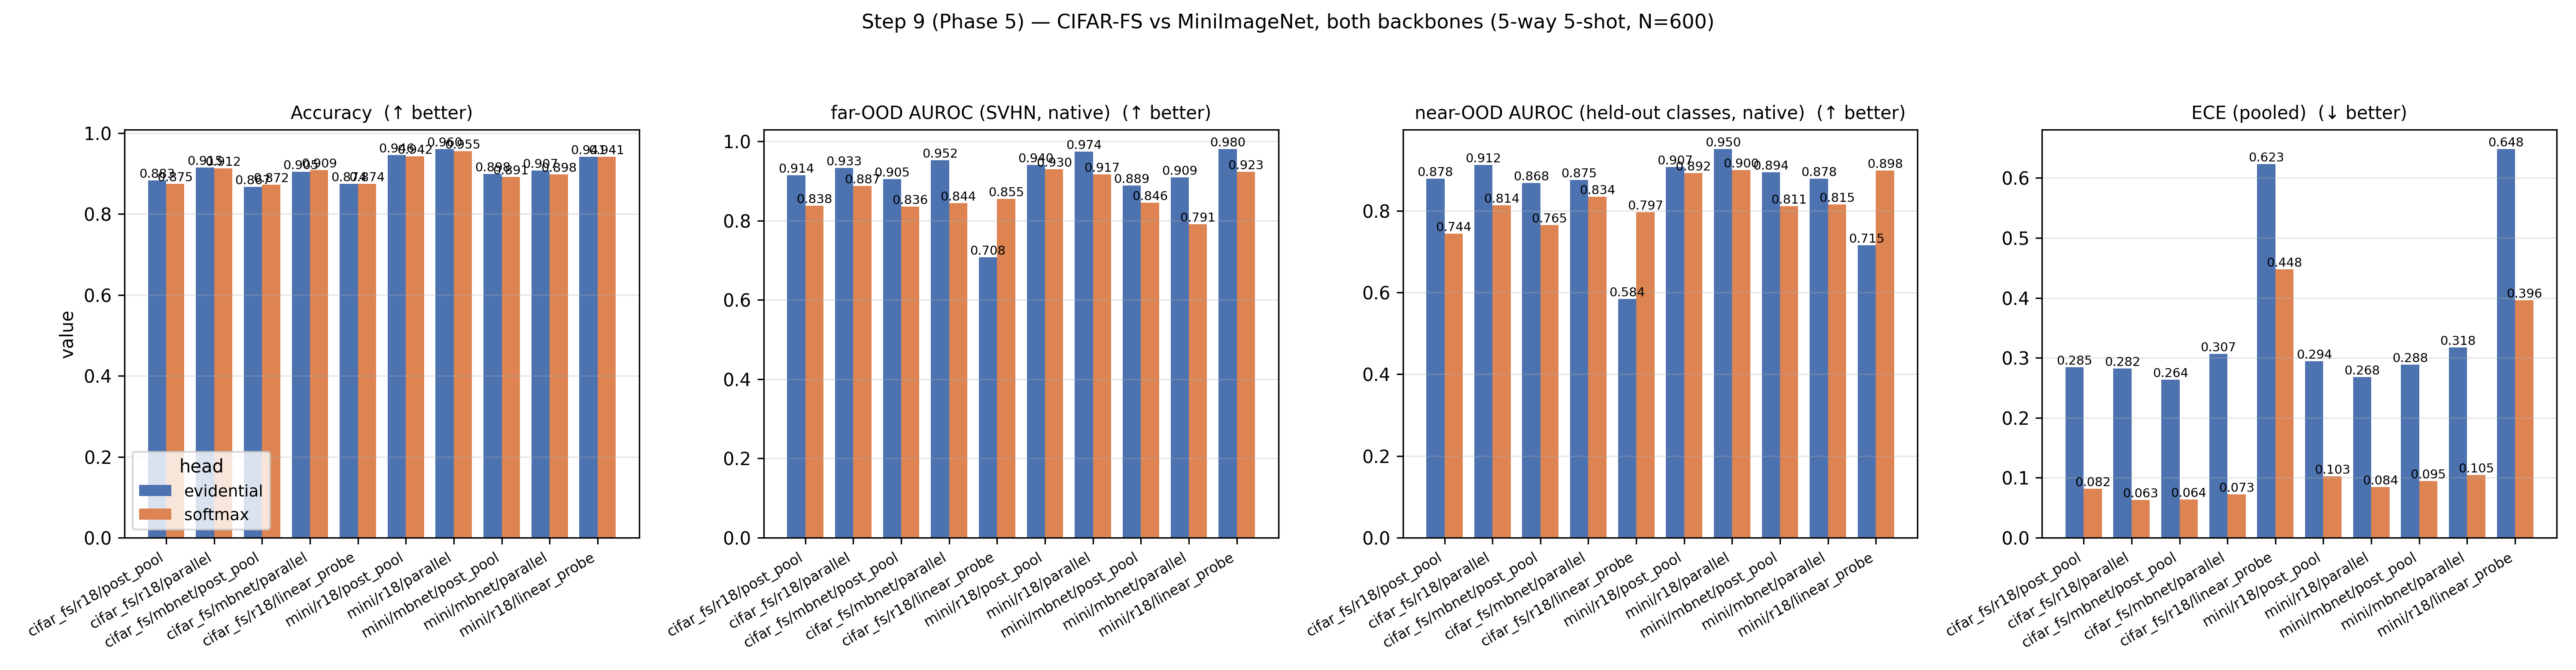

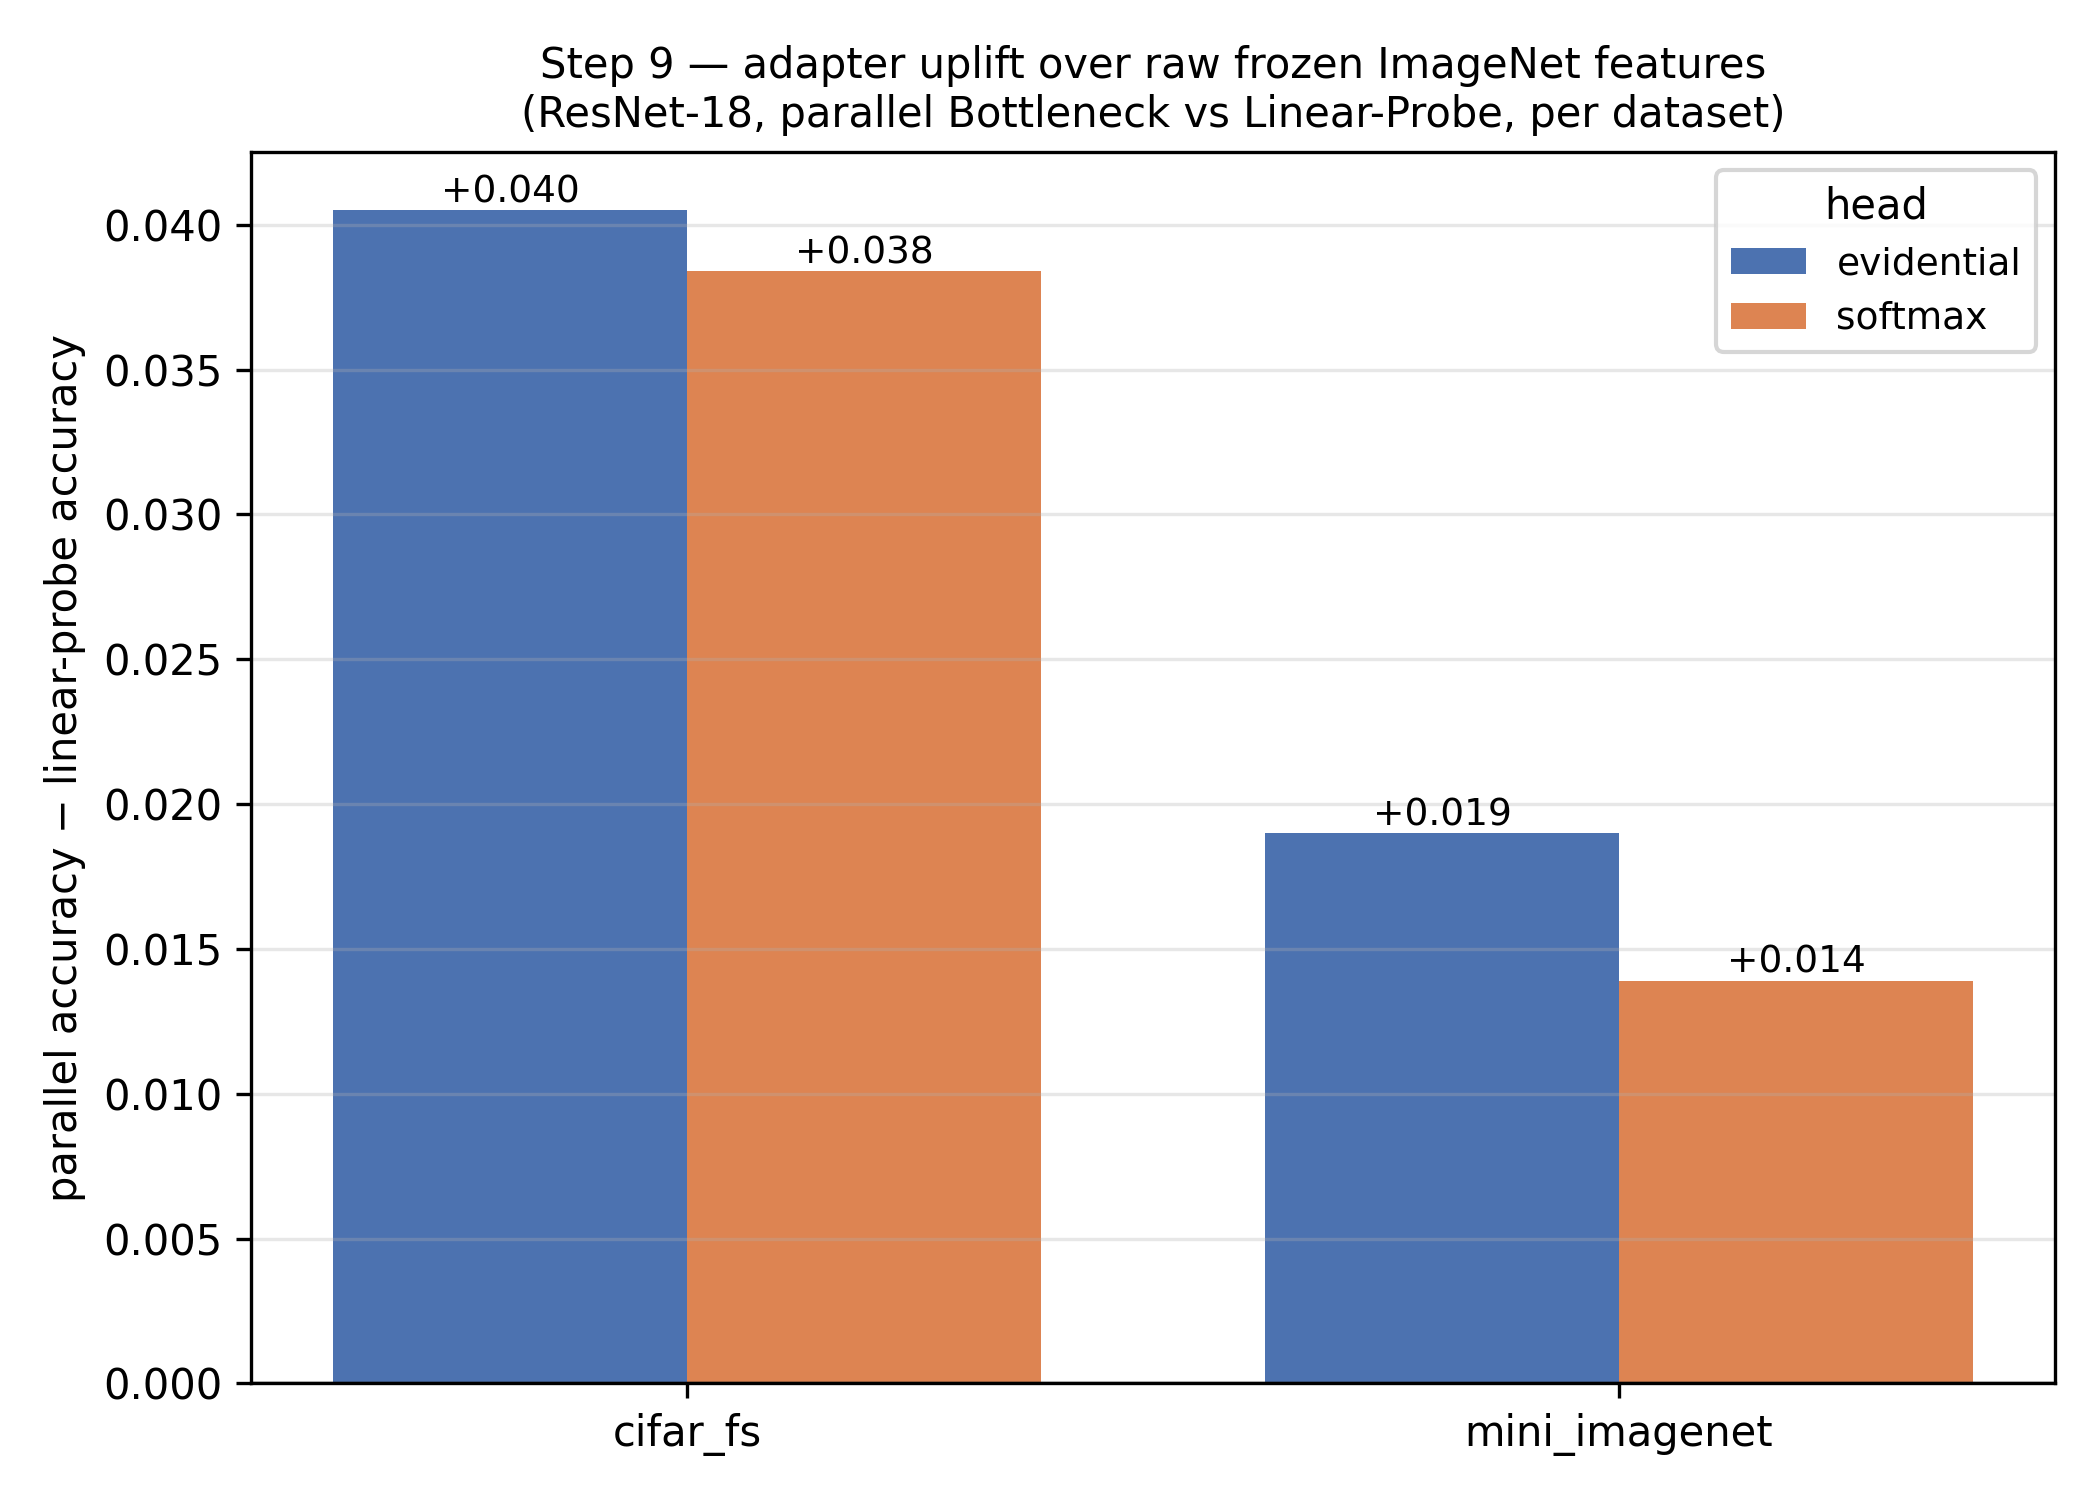

In [14]:
from IPython.display import Image, display
display(Image('results/step9_dataset_comparison.png'))
display(Image('results/step9_adapter_uplift.png'))


## 9. Download the models + results

Packs everything worth keeping into **one zip at `/kaggle/working`**:

* `checkpoints/*.pt` — the 10 trained adapters (**the models**)
* `results/phase5_mini*` + `phase5_dataset_table.json` + the 2 Step 9 PNGs
* `MANIFEST.txt` — sizes, sha256, git commit, so a downloaded bundle is traceable

Three ways to get it off Kaggle: the **link this cell prints**, the **Output**
panel on the right, or `Save Version` → the version's *Output* tab. Commit the
`results/*` files into the repo locally; checkpoints stay out of git.

In [15]:
import glob, hashlib, os, subprocess, zipfile
from pathlib import Path

REPO_DIR = '/kaggle/working/thesis'
os.chdir(REPO_DIR)
ZIP = '/kaggle/working/step9_mini_artifacts.zip'

MODELS  = sorted(glob.glob('checkpoints/model_phase2_mini_*.pt'))
RESULTS = (sorted(glob.glob('results/phase5_mini*'))
           + [p for p in ['results/phase5_dataset_table.json',
                          'results/step9_dataset_comparison.png',
                          'results/step9_adapter_uplift.png'] if os.path.exists(p)])

print(f'{len(MODELS)} model checkpoint(s), {len(RESULTS)} result file(s)')
if len(MODELS) < 10:
    print('[warn] fewer than 10 checkpoints — did every config train?')

def sha256(p, buf=1 << 20):
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for chunk in iter(lambda: f.read(buf), b''):
            h.update(chunk)
    return h.hexdigest()

commit = subprocess.run(['git', 'log', '--oneline', '-1'],
                        capture_output=True, text=True).stdout.strip()
lines = [
    'Step 9 -- MiniImageNet as a second in-distribution dataset (Phase 5, RQ2/RQ3 breadth)',
    f'repo commit: {commit}',
    'protocol   : 5-way 5-shot, 600 frozen test seeds (0..599), both CIFAR-FS and MiniImageNet',
    'OOD pools  : svhn_far, gaussian_far, mini_near, tin_near (wnid-filtered) (500 each)',
    '',
    'FILES (size / sha256):',
]
for p in MODELS + RESULTS:
    lines.append(f'  {p:70s} {os.path.getsize(p)/1e6:8.2f} MB  {sha256(p)[:16]}')
Path('MANIFEST.txt').write_text('\n'.join(lines) + '\n')
print('\n'.join(lines))

with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in MODELS + RESULTS + ['MANIFEST.txt']:
        z.write(p, arcname=p)
print(f'\nwrote {ZIP}  ({os.path.getsize(ZIP)/1e6:.1f} MB)')

os.chdir('/kaggle/working')
from IPython.display import FileLink, display
display(FileLink(os.path.basename(ZIP)))
os.chdir(REPO_DIR)


10 model checkpoint(s), 43 result file(s)
Step 9 -- MiniImageNet as a second in-distribution dataset (Phase 5, RQ2/RQ3 breadth)
repo commit: 6c42070 step 9 fix round 1
protocol   : 5-way 5-shot, 600 frozen test seeds (0..599), both CIFAR-FS and MiniImageNet
OOD pools  : svhn_far, gaussian_far, mini_near, tin_near (wnid-filtered) (500 each)

FILES (size / sha256):
  checkpoints/model_phase2_mini_linear_probe_prototype-evidential_seed42.pt    44.79 MB  25f7c165a2555d17
  checkpoints/model_phase2_mini_linear_probe_prototype-softmax_seed42.pt    44.79 MB  308cddc133d0c28b
  checkpoints/model_phase2_mini_mbnet_parallel_prototype-evidential_seed42.pt     3.90 MB  47a20500d1763dbc
  checkpoints/model_phase2_mini_mbnet_parallel_prototype-softmax_seed42.pt     3.90 MB  5073834a61826e1a
  checkpoints/model_phase2_mini_mbnet_postpool_prototype-evidential_seed42.pt     3.94 MB  85591d8c02a99c02
  checkpoints/model_phase2_mini_mbnet_postpool_prototype-softmax_seed42.pt     3.94 MB  d2df50fd113857d1

/kaggle/working/step9_mini_artifacts.zip

### Optional: download the files individually instead

Skip the zip and grab single files (handy if you only want the JSONs).

In [16]:
import os, glob
from IPython.display import FileLink, display
os.chdir('/kaggle/working')
for p in (sorted(glob.glob('thesis/results/phase5_mini*'))
          + sorted(glob.glob('thesis/results/step9_*'))
          + sorted(glob.glob('thesis/checkpoints/model_phase2_mini_*.pt'))):
    if os.path.exists(p):
        display(FileLink(p))
os.chdir('/kaggle/working/thesis')


/kaggle/working/thesis/results/phase5_mini_linear_probe_prototype-evidential_confusion_matrix.png

/kaggle/working/thesis/results/phase5_mini_linear_probe_prototype-evidential_metrics.json

/kaggle/working/thesis/results/phase5_mini_linear_probe_prototype-evidential_ood_histogram.png

/kaggle/working/thesis/results/phase5_mini_linear_probe_prototype-evidential_reliability.png

/kaggle/working/thesis/results/phase5_mini_linear_probe_prototype-softmax_confusion_matrix.png

...

/kaggle/working/thesis/checkpoints/model_phase2_mini_mbnet_postpool_prototype-softmax_seed42.pt

/kaggle/working/thesis/checkpoints/model_phase2_mini_parallel_prototype-evidential_seed42.pt

/kaggle/working/thesis/checkpoints/model_phase2_mini_parallel_prototype-softmax_seed42.pt

/kaggle/working/thesis/checkpoints/model_phase2_mini_postpool_prototype-evidential_seed42.pt

/kaggle/working/thesis/checkpoints/model_phase2_mini_postpool_prototype-softmax_seed42.pt

## 10. After the run — what to write down

1. Transcribe the §8 table into `step_writeups/step9.txt` §4 (**copy the
   numbers, never retype from memory** — honesty rule,
   `thesis_implementation_instructions.txt` §6).
2. Note each run's `best_val_epoch` and the linear-probe uplift numbers from
   `step9_adapter_uplift.png` — the uplift is the honest answer to "does the
   adapter do anything on a dataset the backbone already knows."
3. Note whether accuracy is in fact near-saturated on MiniImageNet as
   expected from the ImageNet-pretraining overlap — if it ISN'T (i.e. it's
   surprisingly low), suspect a label-mapping bug in the cache builder before
   reporting anything.
4. Tick Step 9's boxes in `progress.txt` and record the headline there.
5. Commit `results/phase5_mini*`, `results/phase5_dataset_table.json` and the
   two PNGs locally (a human commits — never the agent).